=== TMFG: 1億回スケール・モンテカルロシミュレーション開始 ===
N =       1,000 | 最終分断度 = 0.858209 | 誤差 = 0.00113943 | 時間 = 0.01秒
N =      10,000 | 最終分断度 = 0.859303 | 誤差 = 0.00035801 | 時間 = 0.05秒
N =      30,000 | 最終分断度 = 0.859543 | 誤差 = 0.00020296 | 時間 = 0.14秒
N =      50,000 | 最終分断度 = 0.859375 | 誤差 = 0.00015638 | 時間 = 0.22秒
N =     100,000 | 最終分断度 = 0.859576 | 誤差 = 0.00011087 | 時間 = 0.46秒
N =   1,000,000 | 最終分断度 = 0.859495 | 誤差 = 0.00003499 | 時間 = 5.14秒
N =  10,000,000 | 最終分断度 = 0.859486 | 誤差 = 0.00001106 | 時間 = 70.63秒
N = 100,000,000 | 最終分断度 = 0.859484 | 誤差 = 0.00000350 | 時間 = 703.51秒


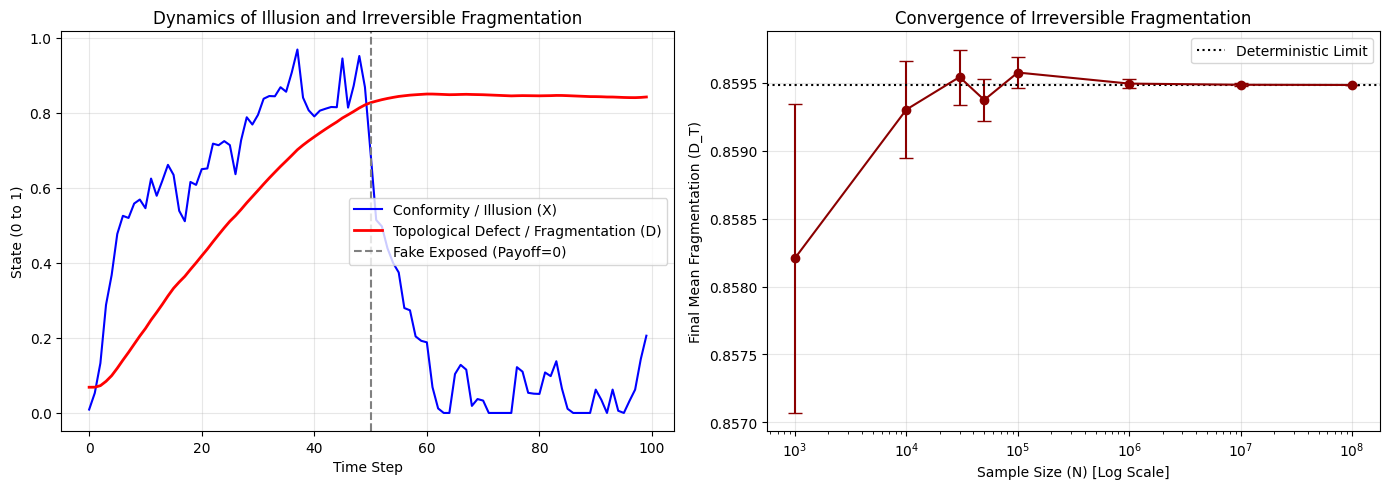


全データを TMFG_Simulation_Results.zip に保存しました。ダウンロードを開始します。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import zipfile
import os
from tqdm import tqdm

# ==========================================
# TMFG (Topological Mean Field Games)
# 不可逆な社会的排除とヒステリシス検証シミュレーター
# ==========================================

# 出力用ディレクトリの作成
OUTPUT_DIR = "output_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def run_tmfg_simulation_batch(N, T_steps=100, dt=0.1, batch_size=10_000_000):
    """
    メモリクラッシュを防ぐため、巨大Nをバッチ分割して計算するモンテカルロシミュレーション
    """
    # パラメータ設定の数理的根拠
    sigma = 0.2          # 認知ノイズ（エージェントの受容のばらつき）
    k_break = 0.5        # リンク切断（排除）のスピード
    k_restore = 0.5      # リンク修復のスピード（切断と同等に設定しバイアスを排除）
    gamma = 5.0          # トポロジカル・ペナルティ（分断の穴が広がるほど修復不能になる係数）

    T_expose = T_steps // 2  # フェイクが暴露され、期待利得がゼロになるタイミング

    sum_D_final = 0.0
    sum_D_sq_final = 0.0

    sample_X_history = np.zeros(T_steps)
    sample_D_history = np.zeros(T_steps)

    num_batches = int(np.ceil(N / batch_size))

    for b_idx in range(num_batches):
        current_batch_size = min(batch_size, N - b_idx * batch_size)

        # モデルの正当性強化：初期状態の完全乱数化
        # 全員が0という決定論的状態ではなく、実社会の多様なばらつきを表現
        X = np.random.uniform(0.0, 0.2, current_batch_size).astype(np.float32)
        D = np.random.uniform(0.0, 0.1, current_batch_size).astype(np.float32)

        for t in range(T_steps):
            # フェーズ制御: 前半はフェイクによる偽の利得(b=0.8)、後半は暴露され利得ゼロ(b=0.0)
            b_t = 0.8 if t < T_expose else 0.0

            # ブラウン運動（確率的ゆらぎ）の動的生成
            dW = np.random.normal(0, np.sqrt(dt), current_batch_size).astype(np.float32)

            # 1. 意見・同調度の更新
            dX = (b_t - X) * dt + sigma * dW
            X = np.clip(X + dX, 0.0, 1.0)

            # 2. 分断の穴（Topological Defect）の更新とペナルティ
            repair_penalty = np.exp(-gamma * D)
            dD = k_break * X * (1.0 - D) * dt - k_restore * (1.0 - X) * D * repair_penalty * dt
            D = np.clip(D + dD, 0.0, 1.0)

            if b_idx == 0:
                sample_X_history[t] = X[0]
                sample_D_history[t] = D[0]

        sum_D_final += np.sum(D)
        sum_D_sq_final += np.sum(D**2)

    mean_D = sum_D_final / N
    var_D = (sum_D_sq_final / N) - (mean_D**2)
    std_err = np.sqrt(max(var_D, 0)) / np.sqrt(N)

    return mean_D, std_err, sample_X_history, sample_D_history

# ==========================================
# 1. 巨大スケールでの計算実験実行
# ==========================================
# 1000 から 1億(100_000_000)までのスケールを検証
N_list = [1_000, 10_000, 30_000, 50_000, 100_000, 1_000_000, 10_000_000, 100_000_000]

results = []
print("=== TMFG: 1億回スケール・モンテカルロシミュレーション開始 ===")

for N in N_list:
    start_time = time.time()
    mean_D, std_err, X_hist, D_hist = run_tmfg_simulation_batch(N)
    elapsed = time.time() - start_time

    results.append({
        'N': N,
        'Mean_Fragmentation_D': mean_D,
        'Standard_Error': std_err,
        'Time_sec': elapsed
    })
    print(f"N = {N:>11,} | 最終分断度 = {mean_D:.6f} | 誤差 = {std_err:.8f} | 時間 = {elapsed:.2f}秒")

    # 試行ごとの履歴をCSVに保存
    df_hist = pd.DataFrame({'TimeStep': range(len(X_hist)), 'X_Conformity': X_hist, 'D_Defect': D_hist})
    df_hist.to_csv(f"{OUTPUT_DIR}/history_N_{N}.csv", index=False)

# 全体サマリーをCSVに保存
df_results = pd.DataFrame(results)
df_results.to_csv(f"{OUTPUT_DIR}/summary_results.csv", index=False)

# ==========================================
# 2. 結果の可視化とZIP化
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

T_steps = len(X_hist)
time_axis = np.arange(T_steps)
ax1.plot(time_axis, X_hist, label='Conformity / Illusion (X)', color='blue')
ax1.plot(time_axis, D_hist, label='Topological Defect / Fragmentation (D)', color='red', linewidth=2)
ax1.axvline(x=T_steps//2, color='gray', linestyle='--', label='Fake Exposed (Payoff=0)')
ax1.set_title('Dynamics of Illusion and Irreversible Fragmentation')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('State (0 to 1)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.errorbar(df_results['N'], df_results['Mean_Fragmentation_D'],
             yerr=df_results['Standard_Error'], fmt='-o', color='darkred', capsize=5)
ax2.set_xscale('log')
ax2.set_title('Convergence of Irreversible Fragmentation')
ax2.set_xlabel('Sample Size (N) [Log Scale]')
ax2.set_ylabel('Final Mean Fragmentation (D_T)')
ax2.axhline(y=df_results['Mean_Fragmentation_D'].iloc[-1], color='black', linestyle=':', label='Deterministic Limit')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/simulation_plots.png", dpi=300)
plt.show()

# 出力結果をZIPにまとめる
zip_filename = "TMFG_Simulation_Results.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(OUTPUT_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path, arcname=file)

print(f"\n全データを {zip_filename} に保存しました。ダウンロードを開始します。")

try:
    from google.colab import files
    files.download(zip_filename)
except ImportError:
    print("ローカル環境のためダウンロードはスキップされました。")